# 06 - Regime Analysis and Explainability

Diagnose walk-forward performance across trailing volatility and trend regimes, then inspect the features driving the latest research signal.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.backtester import run_backtest
from src.data_loader import load_processed_data, load_raw_data
from src.explainability import explain_latest_prediction, get_feature_importance
from src.features import create_features, get_feature_columns
from src.models import train_random_forest
from src.regimes import add_trend_regime, add_volatility_regime, evaluate_by_regime
from src.walk_forward import run_walk_forward_validation

In [2]:
dataset = load_processed_data("SPY", PROJECT_ROOT / "data" / "processed")
feature_cols = get_feature_columns(dataset)
regime_dataset = add_volatility_regime(dataset, lookback=252)
regime_dataset = add_trend_regime(regime_dataset)

regime_dataset[["date", "close", "volatility_regime", "trend_regime"]].tail()

,date,close,volatility_regime,trend_regime
4103,2026-05-27,750.460022,low_volatility,uptrend
4104,2026-05-28,754.599976,low_volatility,uptrend
4105,2026-05-29,756.479980,low_volatility,uptrend
4106,2026-06-01,758.539978,low_volatility,uptrend
4107,2026-06-02,759.570007,low_volatility,uptrend


In [3]:
walk_forward = run_walk_forward_validation(
    regime_dataset,
    feature_cols,
    train_random_forest,
    train_window=1_000,
    test_window=100,
    step_size=100,
    purge_rows=5,
)

regime_columns = regime_dataset.loc[
    walk_forward["source_index"], ["volatility_regime", "trend_regime"]
].reset_index(drop=True)
walk_forward[["volatility_regime", "trend_regime"]] = regime_columns
backtest = run_backtest(walk_forward, transaction_cost=0.0005)
backtest[["date", "prediction", "volatility_regime", "trend_regime", "strategy_return"]].head()

,date,prediction,volatility_regime,trend_regime,strategy_return
0,2014-01-30,1,high_volatility,sideways,0.000000
1,2014-01-31,1,high_volatility,sideways,-0.006359
2,2014-02-03,1,high_volatility,sideways,-0.022505
3,2014-02-04,1,high_volatility,sideways,0.007005
4,2014-02-05,1,high_volatility,sideways,-0.001255


In [4]:
volatility_performance = evaluate_by_regime(backtest, "volatility_regime")
trend_performance = evaluate_by_regime(backtest, "trend_regime")

print("Volatility regime performance")
display(volatility_performance)
print("Trend regime performance")
display(trend_performance)

Volatility regime performance


,regime,number_of_rows,average_strategy_return,total_strategy_return,sharpe,max_drawdown,win_rate,accuracy
0,high_volatility,1047,-0.000361,-0.398940,-0.361866,-0.495615,0.509250,0.460363
1,low_volatility,1155,0.000150,0.167847,0.424006,-0.233925,0.491506,0.364502
2,normal_volatility,901,-0.000689,-0.477254,-1.393138,-0.529799,0.430730,0.329634


Trend regime performance


,regime,number_of_rows,average_strategy_return,total_strategy_return,sharpe,max_drawdown,win_rate,accuracy
0,downtrend,334,-0.002688,-0.621047,-2.069439,-0.634374,0.443114,0.511976
1,sideways,917,0.000297,0.223308,0.377920,-0.425412,0.510662,0.439477
2,uptrend,1852,-0.000108,-0.208460,-0.284199,-0.382713,0.470588,0.338013


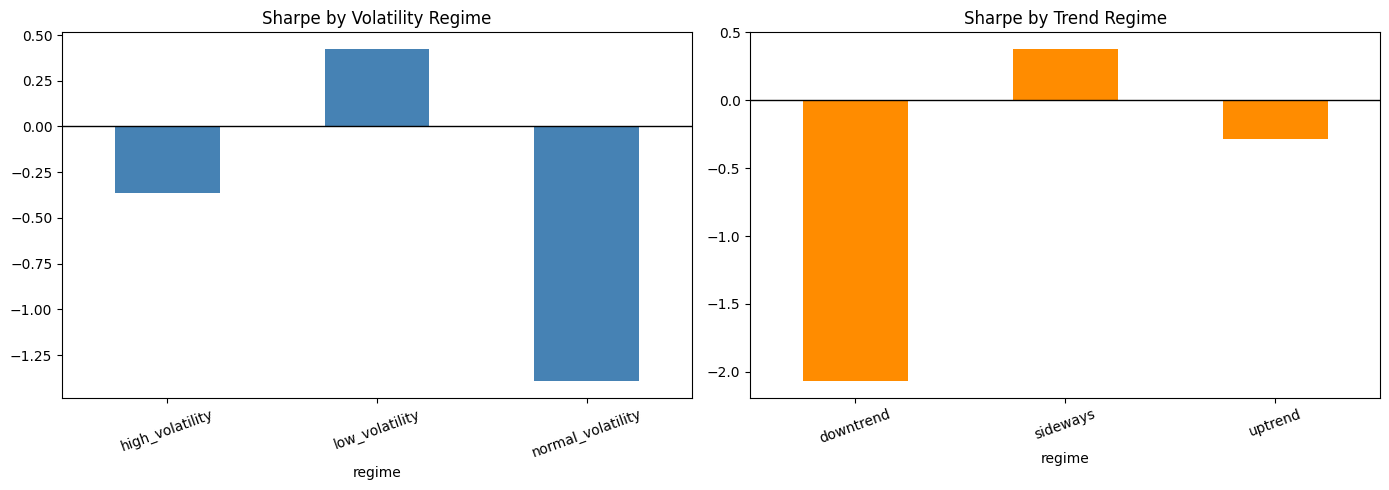

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(14, 5))
volatility_performance.plot.bar(x="regime", y="sharpe", ax=axes[0], legend=False, color="steelblue")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Sharpe by Volatility Regime")
axes[0].tick_params(axis="x", rotation=20)

trend_performance.plot.bar(x="regime", y="sharpe", ax=axes[1], legend=False, color="darkorange")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Sharpe by Trend Regime")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

In [6]:
latest_model = train_random_forest(regime_dataset[feature_cols], regime_dataset["target"])
latest_features = add_trend_regime(add_volatility_regime(create_features(load_raw_data("SPY", PROJECT_ROOT / "data" / "raw")), lookback=252))
latest_row = latest_features.tail(1)
latest_explanation = explain_latest_prediction(latest_model, latest_row, feature_cols, top_n=10)

print(f"Latest feature date: {latest_row['date'].iloc[0].date()}")
print(f"Latest research signal: {latest_explanation['prediction']}")
print(f"Confidence: {latest_explanation['confidence']:.3f}")
print(f"Volatility regime: {latest_row['volatility_regime'].iloc[0]}")
print(f"Trend regime: {latest_row['trend_regime'].iloc[0]}")
pd.DataFrame(latest_explanation["top_features"])

Latest feature date: 2026-06-02
Latest research signal: 0
Confidence: 0.358
Volatility regime: low_volatility
Trend regime: uptrend


,feature,importance,direction,method,value
0,volatility_10,0.059161,NaN,tree_importance,0.071008
1,atr_pct,0.059122,NaN,tree_importance,0.008605
2,volatility_5,0.050699,NaN,tree_importance,0.033234
3,volatility_20,0.050686,NaN,tree_importance,0.094936
4,rsi_14,0.047288,NaN,tree_importance,71.165646
5,ema_10_20_ratio,0.047026,NaN,tree_importance,0.012470
6,ema_50,0.046494,NaN,tree_importance,719.627101
7,ema_20,0.046386,NaN,tree_importance,741.795179
8,macd,0.045549,NaN,tree_importance,12.876614
9,macd_diff,0.045497,NaN,tree_importance,-0.033353


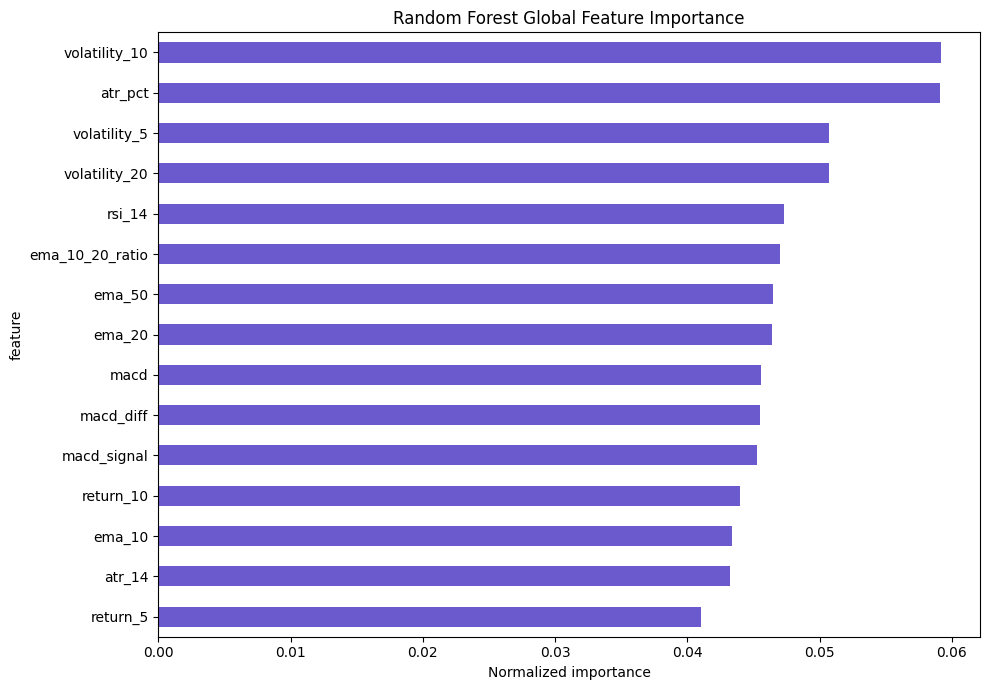

In [7]:
importance = get_feature_importance(latest_model, feature_cols).head(15).sort_values("importance")
importance.plot.barh(x="feature", y="importance", figsize=(10, 7), legend=False, color="slateblue", title="Random Forest Global Feature Importance")
plt.xlabel("Normalized importance")
plt.tight_layout()
plt.show()

## Interpretation

Regime labels use only information available at or before each row. Conditional results help identify when a signal fails, but they do not justify selecting regimes after observing outcomes. Tree feature importance is global and does not establish causal impact.